# EE 344 — Assignment 5: Power-System Fault Classification with Deep Neural Networks

In this assignment, you will predict **power-system fault conditions** from 6 input measurements using **PyTorch**.
There are many ways to implement DNNs for prediction tasks; here you will implement and compare **three** common setups.

**Dataset**: `classData.csv`

**Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`  
**Outputs**: 4-bit label `[G, C, B, A]`

Dataset (Kaggle): https://www.kaggle.com/datasets/esathyaprakash/electrical-fault-detection-and-classification

**Note:** Do **NOT** download the dataset from Kaggle. Use the dataset file provided on Canvas with this assignment.

Your tasks:
1. **Part 1** — Regression-style DNN to predict 4 outputs (then round to bits).
2. **Part 2** — Multi-label DNN to predict 4 bits (sigmoid / BCE-style loss).
3. **Part 3** — Multi-class DNN to predict no fault and 5 fault types (softmax / cross-entropy).
4. **Part 4** — Brief discussion: which approach is best and why.
5. **Part 5** — Open-ended: build a **binary** classifier (Fault vs No Fault) using the best approach.


## Setup
Run the next cell to import libraries and define helper functions.

In [4]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import matplotlib.pyplot as plt

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

def plot_cm(cm, title, labels):
    plt.figure()
    plt.imshow(cm, interpolation='nearest')
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha='right')
    plt.yticks(ticks, labels)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.tight_layout()
    plt.show()

def bit_reports(Y_true_bits, Y_pred_bits, split_name='Test', bit_names=('G','C','B','A')):
    """Multi-label report + per-bit 2x2 confusion matrices."""
    print(f"\n=== Bit-level Report | {split_name} ===")
    print(classification_report(Y_true_bits, Y_pred_bits, target_names=list(bit_names), digits=4))
    for j, lab in enumerate(bit_names):
        cm = confusion_matrix(Y_true_bits[:, j], Y_pred_bits[:, j], labels=[0, 1])
        print(f"\nBit {lab} | {split_name} CM (rows=true 0/1, cols=pred 0/1):\n{cm}")


Device: cpu


## Dataset

The file `classData.csv` contains a dataset for classifying fault conditions.

- **Inputs**: `[Ia, Ib, Ic, Va, Vb, Vc]`
- **Outputs**: `[G, C, B, A]`

Examples:
- `[0 0 0 0]` — No Fault
- `[1 0 0 1]` — LG fault (Phase A to ground)
- `[0 0 1 1]` — LL fault (Phase A to Phase B)
- `[1 0 1 1]` — LLG fault (Phases A,B to ground)
- `[0 1 1 1]` — LLL fault (all three phases)
- `[1 1 1 1]` — LLLG fault (three phases + ground)


In [5]:
# ----------------------------
# Load data + create targets
# ----------------------------
CSV_PATH = 'classData.csv'
df = pd.read_csv(CSV_PATH)

label_cols = ['G','C','B','A']
feature_cols = ['Ia','Ib','Ic','Va','Vb','Vc']

missing = [c for c in (label_cols + feature_cols) if c not in df.columns]
if missing:
    raise ValueError(f"Missing expected columns: {missing}. Found: {list(df.columns)}")

X = df[feature_cols].astype(np.float32).values            # (N,6)
Y_bits = df[label_cols].astype(int).values                # (N,4)

FAULT_NAMES = ['No Fault','LG','LL','LLG','LLL','LLLG']

def bits_to_fault_type_idx(bits_gcba):
    G, C, B, A = map(int, bits_gcba)
    n_phase = C + B + A
    if G == 0 and n_phase == 0: return 0
    if G == 1 and n_phase == 1: return 1
    if G == 0 and n_phase == 2: return 2
    if G == 1 and n_phase == 2: return 3
    if G == 0 and n_phase == 3: return 4
    if G == 1 and n_phase == 3: return 5
    raise ValueError(f"Unexpected pattern [G,C,B,A]={bits_gcba}")

y_fault = np.array([bits_to_fault_type_idx(row) for row in Y_bits], dtype=int)
print('Fault counts:', dict(zip(FAULT_NAMES, np.bincount(y_fault, minlength=len(FAULT_NAMES)))))

# One shared split (recommended for fair comparison across Parts 1–3)
X_train, X_test, Y_train, Y_test, y_fault_train, y_fault_test = train_test_split(
    X, Y_bits, y_fault, test_size=0.30, random_state=RANDOM_STATE, stratify=y_fault
)
print('Train size:', X_train.shape[0], '| Test size:', X_test.shape[0])


Fault counts: {'No Fault': 2365, 'LG': 1129, 'LL': 1004, 'LLG': 1134, 'LLL': 1096, 'LLLG': 1133}
Train size: 5502 | Test size: 2359


## Part 1 — DNN Model 1 (Regression-style 4-output model)

You will build a DNN that outputs **4 real-valued numbers** and train it with **MSE**.
During evaluation, you will **round** predictions to the nearest integer, clamp to `{0,1}`, and then compare against the true 4-bit label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 (linear)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**


In [6]:
# ----------------------------
# Part 1: Robust scaling (fit on train only)
# ----------------------------
scaler_1 = RobustScaler()
X_train_s1 = scaler_1.fit_transform(X_train).astype(np.float32)
X_test_s1  = scaler_1.transform(X_test).astype(np.float32)

# Torch datasets
Xtr = torch.from_numpy(X_train_s1)
Xte = torch.from_numpy(X_test_s1)
Ytr = torch.from_numpy(Y_train.astype(np.float32))
Yte = torch.from_numpy(Y_test.astype(np.float32))

BATCH_SIZE = 256
train_loader_1 = DataLoader(TensorDataset(Xtr, Ytr), batch_size=BATCH_SIZE, shuffle=True)

# Hyperparameters
INPUT_DIM = 6
H1 = 16
H2 = 8
OUT_DIM = 4
DROPOUT_P = 0.25
L2_WEIGHT_DECAY = 1e-4
LR = 1e-3
EPOCHS = 1000


In [7]:
# Define the DNN for Part 1 using PyTorch.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: linear (no activation)
# - Use BatchNorm and Dropout in hidden layers
#
# Write your model class below.

class DNN_Reg4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        
        self.net = nn.Sequential(
            # 6 -> 16
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),
            
            # 16 -> 8
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),
            
            # 8 -> 4 (linear output)
            nn.Linear(h2, out_dim)
        )

    def forward(self, x):
        return self.net(x)


In [8]:
# Create the model, loss function, and optimizer.
# - Loss: MSE
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_Reg4().to(device)
loss_fn = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)



In [11]:
# ----------------------------
# Training loop (you fill the key missing pieces)
# ----------------------------
def train_part1(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            
            preds = model(xb)
            
            loss = loss_fn(preds, yb)
            
            loss.backward()

            optimizer.step()

            total += loss.item() * xb.size(0)
            if ep in [1, epochs // 2, epochs]: 
                avg_loss = total / len(loader.dataset) 
                print(f"Epoch {ep}/{epochs} | Loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_part1(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    out = model(X_t).cpu().numpy()  # (N,4) real-valued
    return out

train_part1(model, train_loader_1)


Epoch 1/1000 | Loss: 0.040753
Epoch 1/1000 | Loss: 0.078882
Epoch 1/1000 | Loss: 0.118729
Epoch 1/1000 | Loss: 0.158600
Epoch 1/1000 | Loss: 0.196743
Epoch 1/1000 | Loss: 0.233842
Epoch 1/1000 | Loss: 0.273350
Epoch 1/1000 | Loss: 0.308990
Epoch 1/1000 | Loss: 0.348020
Epoch 1/1000 | Loss: 0.383660
Epoch 1/1000 | Loss: 0.417406
Epoch 1/1000 | Loss: 0.456296
Epoch 1/1000 | Loss: 0.492993
Epoch 1/1000 | Loss: 0.528807
Epoch 1/1000 | Loss: 0.559814
Epoch 1/1000 | Loss: 0.591564
Epoch 1/1000 | Loss: 0.625131
Epoch 1/1000 | Loss: 0.656423
Epoch 1/1000 | Loss: 0.687561
Epoch 1/1000 | Loss: 0.721770
Epoch 1/1000 | Loss: 0.753636
Epoch 1/1000 | Loss: 0.766126
Epoch 500/1000 | Loss: 0.004439
Epoch 500/1000 | Loss: 0.009649
Epoch 500/1000 | Loss: 0.014185
Epoch 500/1000 | Loss: 0.019188
Epoch 500/1000 | Loss: 0.023977
Epoch 500/1000 | Loss: 0.028315
Epoch 500/1000 | Loss: 0.033014
Epoch 500/1000 | Loss: 0.037544
Epoch 500/1000 | Loss: 0.042601
Epoch 500/1000 | Loss: 0.047263
Epoch 500/1000 | Los

In [12]:
# ----------------------------
# Evaluation (round -> clamp to {0,1} -> report)
# ----------------------------
yhat_train = predict_part1(model, X_train_s1)
yhat_test  = predict_part1(model, X_test_s1)

# After you obtain yhat_* (shape N x 4):
pred_bits_train = np.clip(np.rint(yhat_train).astype(int), 0, 1)
pred_bits_test  = np.clip(np.rint(yhat_test ).astype(int), 0, 1)
bit_reports(Y_train, pred_bits_train, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.8835    0.7880    0.8330      2377
           C     0.9919    0.9178    0.9534      2263
           B     0.9458    0.9653    0.9555      3057
           A     0.9778    0.9796    0.9787      3144

   micro avg     0.9520    0.9207    0.9361     10841
   macro avg     0.9497    0.9127    0.9301     10841
weighted avg     0.9510    0.9207    0.9349     10841
 samples avg     0.6593    0.6501    0.6490     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[2878  247]
 [ 504 1873]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[3222   17]
 [ 186 2077]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[2276  169]
 [ 106 2951]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[2288   70]
 [  64 3080]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.8861    0.7713    0.8248      1019
           C     0.9856    

/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/t.yan/anaconda3/lib/python3.1

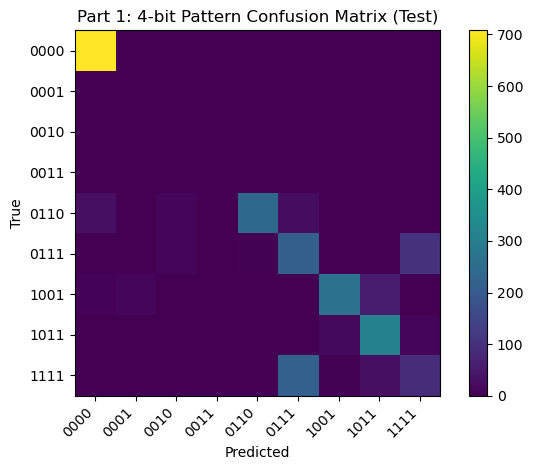

[[708   1   0   0   0   0   1   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0]
 [ 28   0  11   0 238  24   0   0   0]
 [  0   0  11   0   4 214   0   0 100]
 [  6  10   0   0   0   0 267  56   0]
 [  0   0   0   1   0   0  14 312  13]
 [  0   0   0   0   0 216   4  29  91]]


In [13]:
# One confusion matrix over full 4-bit patterns (for TEST set)
true_str = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str = [''.join(map(str, r.tolist())) for r in pred_bits_test]
labels = sorted(list(set(true_str) | set(pred_str)))
cm = confusion_matrix(true_str, pred_str, labels=labels)
plot_cm(cm, 'Part 1: 4-bit Pattern Confusion Matrix (Test)', labels)
print(cm)

## Part 2 — DNN Model 2 (Multi-label 4-bit classification)

You will build a DNN that predicts the 4 bits `[G, C, B, A]` as a **multi-label** output.
Each output dimension is an independent binary label.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 4 logits (apply sigmoid only for evaluation)
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use a **binary cross-entropy style loss on logits** (do not apply sigmoid inside the model).


In [14]:
# ----------------------------
# Part 2: Robust scaling (fit on train only)
# ----------------------------
scaler_2 = RobustScaler()
X_train_s2 = scaler_2.fit_transform(X_train).astype(np.float32)
X_test_s2  = scaler_2.transform(X_test).astype(np.float32)

Xtr2 = torch.from_numpy(X_train_s2)
Xte2 = torch.from_numpy(X_test_s2)
Ytr2 = torch.from_numpy(Y_train.astype(np.float32))
Yte2 = torch.from_numpy(Y_test.astype(np.float32))

train_loader_2 = DataLoader(TensorDataset(Xtr2, Ytr2), batch_size=BATCH_SIZE, shuffle=True)


In [15]:
# Define the DNN for Part 2.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 4
# - Hidden activations: ReLU
# - Output: 4 logits (no sigmoid inside the model)
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiLabel4(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, out_dim=OUT_DIM, p_drop=DROPOUT_P):
        super().__init__()
        
        self.net = nn.Sequential(
            # 6 -> 16
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),
            
            # 16 -> 8
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),
            
            # 8 -> 4 (linear output)
            nn.Linear(h2, out_dim)
        )

    def forward(self, x):
        return self.net(x)


In [ ]:
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: binary cross-entropy style loss on logits -- BCEWithLogitsLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay

model = DNN_MultiLabel4().to(device)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)


In [16]:
# ----------------------------
# Training loop scaffold
# ----------------------------
def train_part2(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            
            preds = model(xb)
            
            loss = loss_fn(preds, yb)
            
            loss.backward()

            optimizer.step()

            total += loss.item() * xb.size(0)
            if ep in [1, epochs // 2, epochs]: 
                    avg_loss = total / len(loader.dataset) 
                    print(f"Epoch {ep}/{epochs} | Loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_bits_part2(model, X_np, threshold=0.5):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    probs = torch.sigmoid(logits).cpu().numpy()
    pred_bits = (probs >= threshold).astype(int)
    return pred_bits

train_part2(model, train_loader_2)


Epoch 1/1000 | Loss: 0.005056
Epoch 1/1000 | Loss: 0.010092
Epoch 1/1000 | Loss: 0.014944
Epoch 1/1000 | Loss: 0.019510
Epoch 1/1000 | Loss: 0.024157
Epoch 1/1000 | Loss: 0.029160
Epoch 1/1000 | Loss: 0.033715
Epoch 1/1000 | Loss: 0.038634
Epoch 1/1000 | Loss: 0.044007
Epoch 1/1000 | Loss: 0.048764
Epoch 1/1000 | Loss: 0.053587
Epoch 1/1000 | Loss: 0.058253
Epoch 1/1000 | Loss: 0.063374
Epoch 1/1000 | Loss: 0.068016
Epoch 1/1000 | Loss: 0.072553
Epoch 1/1000 | Loss: 0.077094
Epoch 1/1000 | Loss: 0.081611
Epoch 1/1000 | Loss: 0.086316
Epoch 1/1000 | Loss: 0.090829
Epoch 1/1000 | Loss: 0.095855
Epoch 1/1000 | Loss: 0.100145
Epoch 1/1000 | Loss: 0.102332
Epoch 500/1000 | Loss: 0.004692
Epoch 500/1000 | Loss: 0.009330
Epoch 500/1000 | Loss: 0.014457
Epoch 500/1000 | Loss: 0.019432
Epoch 500/1000 | Loss: 0.023717
Epoch 500/1000 | Loss: 0.028738
Epoch 500/1000 | Loss: 0.033751
Epoch 500/1000 | Loss: 0.038330
Epoch 500/1000 | Loss: 0.043390
Epoch 500/1000 | Loss: 0.048238
Epoch 500/1000 | Los

In [17]:
# ----------------------------
# Evaluation
# ----------------------------
pred_bits_train_ = predict_bits_part2(model, X_train_s2)
pred_bits_test_  = predict_bits_part2(model, X_test_s2)

bit_reports(Y_train, pred_bits_train_, split_name='Train', bit_names=label_cols)
bit_reports(Y_test,  pred_bits_test_,  split_name='Test',  bit_names=label_cols)


=== Bit-level Report | Train ===
              precision    recall  f1-score   support

           G     0.4320    1.0000    0.6034      2377
           C     0.4133    1.0000    0.5849      2263
           B     0.5556    1.0000    0.7143      3057
           A     0.5714    1.0000    0.7273      3144

   micro avg     0.4932    1.0000    0.6606     10841
   macro avg     0.4931    1.0000    0.6575     10841
weighted avg     0.5034    1.0000    0.6667     10841
 samples avg     0.4934    0.6992    0.5689     10841


Bit G | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 3125]
 [   0 2377]]

Bit C | Train CM (rows=true 0/1, cols=pred 0/1):
[[  27 3212]
 [   0 2263]]

Bit B | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 2445]
 [   0 3057]]

Bit A | Train CM (rows=true 0/1, cols=pred 0/1):
[[   0 2358]
 [   0 3144]]

=== Bit-level Report | Test ===
              precision    recall  f1-score   support

           G     0.4320    1.0000    0.6033      1019
           C     0.4144    

/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Recall and F-score are ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


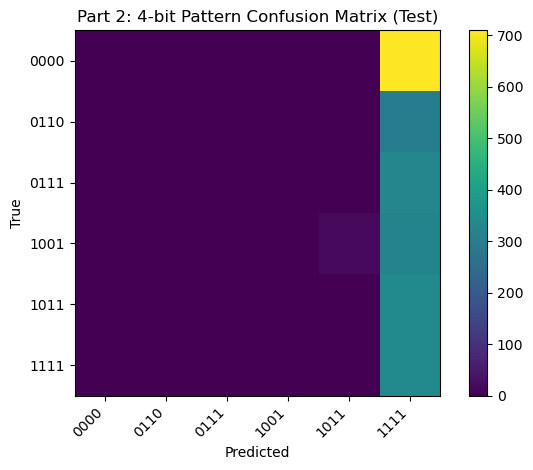

[[  0   0   0   0   0 710]
 [  0   0   0   0   0 301]
 [  0   0   0   0   0 329]
 [  0   0   0   0  18 321]
 [  0   0   0   0   0 340]
 [  0   0   0   0   0 340]]


In [18]:
# One confusion matrix over full 4-bit patterns (For TEST set)
true_str_ = [''.join(map(str, r.tolist())) for r in Y_test]
pred_str_ = [''.join(map(str, r.tolist())) for r in pred_bits_test_]
labels_ = sorted(list(set(true_str_) | set(pred_str_)))
cm_ = confusion_matrix(true_str_, pred_str_, labels=labels_)
plot_cm(cm_, 'Part 2: 4-bit Pattern Confusion Matrix (Test)', labels_)
print(cm_)

## Part 3 — DNN Model 3 (Multi-class fault type classification)

In this part, you will predict one of **6 fault types**.
The 4-bit label is converted to a single class in `{0,1,2,3,4,5}` using the provided mapping.

Model structure:
- Input: 6 features
- Hidden: 16 → 8 (ReLU)
- Output: 6 logits
- Include: **BatchNorm**, **Dropout**, and **L2 regularization**

Training:
- Use **cross-entropy loss** for multi-class classification.


In [21]:
# ----------------------------
# Part 3: Robust scaling (fit on train only)
# ----------------------------
scaler_3 = RobustScaler()
X_train_s3 = scaler_3.fit_transform(X_train).astype(np.float32)
X_test_s3  = scaler_3.transform(X_test).astype(np.float32)

ytr3 = torch.from_numpy(y_fault_train.astype(np.int64))
yte3 = torch.from_numpy(y_fault_test.astype(np.int64))
Xtr3 = torch.from_numpy(X_train_s3)
Xte3 = torch.from_numpy(X_test_s3)

train_loader_3 = DataLoader(TensorDataset(Xtr3, ytr3), batch_size=BATCH_SIZE, shuffle=True)


In [26]:
# Define the DNN for Part 3.
# Requirements:
# - Architecture: 6 -> 16 -> 8 -> 6
# - Hidden activations: ReLU
# - Output: 6 logits
# - Use BatchNorm and Dropout in hidden layers

class DNN_MultiClass6(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, h1=H1, h2=H2, num_classes=6, p_drop=DROPOUT_P):
        super().__init__()
        self.net = nn.Sequential(
                # 6 → 16
                nn.Linear(input_dim, h1),
                nn.BatchNorm1d(h1),
                nn.ReLU(),
                nn.Dropout(p_drop),

                # 16 → 8
                nn.Linear(h1, h2),
                nn.BatchNorm1d(h2),
                nn.ReLU(),
                nn.Dropout(p_drop),

                # 8 → 6 logits
                nn.Linear(h2, num_classes)
            )

    def forward(self, x):
            return self.net(x)

In [27]:
# Create the model, loss function, and optimizer.
# Requirements:
# - Loss: CrossEntropyLoss
# - Optimizer: Adam
# - Include L2 regularization using weight_decay
model_3 = DNN_MultiClass6().to(device)

loss_fn_3 = nn.CrossEntropyLoss()

optimizer_3 = torch.optim.Adam(
    model_3.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)

In [28]:
# ----------------------------
# Training loop scaffold
# ----------------------------
def train_part3(model, loader, epochs=EPOCHS):
    model.train()
    for ep in range(1, epochs + 1):
        total = 0.0
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_3.zero_grad()

            logits = model(xb)

            loss = loss_fn_3(logits, yb)

            loss.backward()

            optimizer_3.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs // 2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch {ep}/{epochs} | Loss: {avg_loss:.6f}")

@torch.no_grad()
def predict_part3(model, X_np):
    model.eval()
    X_t = torch.from_numpy(X_np.astype(np.float32)).to(device)
    logits = model(X_t)
    return torch.argmax(logits, dim=1).cpu().numpy()

train_part3(model_3, train_loader_3)


Epoch 1/1000 | Loss: 1.822833
Epoch 500/1000 | Loss: 0.616925
Epoch 1000/1000 | Loss: 0.587989



=== Part 3 | Train ===
              precision    recall  f1-score   support

    No Fault     0.2415    0.0429    0.0729      1655
          LG     0.0008    0.0013    0.0009       790
          LL     0.2244    0.7340    0.3438       703
         LLG     0.5000    0.9950    0.6655       794
         LLL     0.0000    0.0000    0.0000       767
        LLLG     0.0000    0.0000    0.0000       793

    accuracy                         0.2505      5502
   macro avg     0.1611    0.2955    0.1805      5502
weighted avg     0.1736    0.2505    0.1620      5502



/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


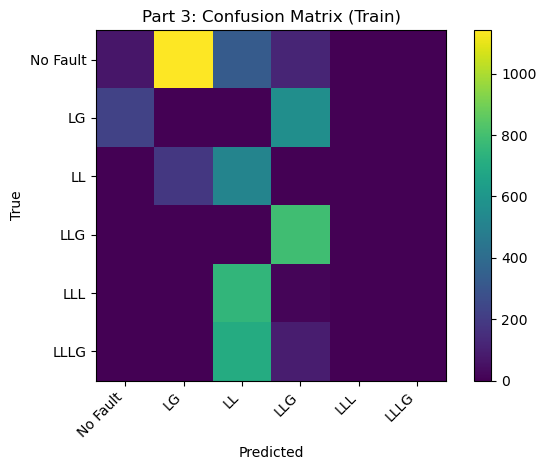


=== Part 3 | Test ===
              precision    recall  f1-score   support

    No Fault     0.2331    0.0437    0.0735       710
          LG     0.0000    0.0000    0.0000       339
          LL     0.2267    0.7442    0.3476       301
         LLG     0.5090    1.0000    0.6746       340
         LLL     0.0000    0.0000    0.0000       329
        LLLG     0.0000    0.0000    0.0000       340

    accuracy                         0.2522      2359
   macro avg     0.1615    0.2980    0.1826      2359
weighted avg     0.1724    0.2522    0.1637      2359



/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/Users/t.yan/anaconda3/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1469: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


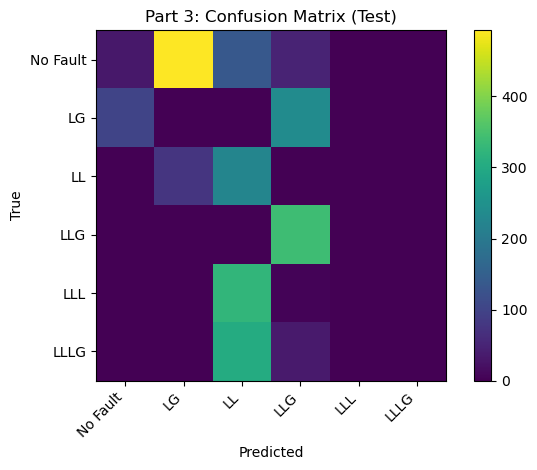

In [29]:
# ----------------------------
# Evaluation
# ----------------------------
pred_train = predict_part3(model, X_train_s3)
pred_test  = predict_part3(model, X_test_s3)

print('\n=== Part 3 | Train ===')
print(classification_report(y_fault_train, pred_train, target_names=FAULT_NAMES, digits=4))
cm_tr = confusion_matrix(y_fault_train, pred_train, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_tr, 'Part 3: Confusion Matrix (Train)', FAULT_NAMES)

print('\n=== Part 3 | Test ===')
print(classification_report(y_fault_test, pred_test, target_names=FAULT_NAMES, digits=4))
cm_te = confusion_matrix(y_fault_test, pred_test, labels=np.arange(len(FAULT_NAMES)))
plot_cm(cm_te, 'Part 3: Confusion Matrix (Test)', FAULT_NAMES)


## Part 4 — Discussion

Answer **2–5 sentences** for each prompt.

1. Compare Parts 1–3. Which formulation fits this dataset best (regression-style, multi-label, or multi-class), and why?
2. When you used the bit-based approaches (Part 1 and Part 2), did you observe any **inconsistent 4-bit outputs** (invalid fault patterns)? What does that suggest?
3. Looking at confusion matrices, which fault types (or bit positions) were the hardest to predict? Give one plausible reason.

### Your answers
- Q1:Part 3. It treats the six fault types as a simple selection, each sample belongs to exactly one of six mutually exclusive fault types. By using a multi-class model with cross-entropy, we force the AI to pick exactly one valid fault type from the list.
- Q2: inconsistent 4-bit outputs does occur because each bit is predicted independently.
- Q3: ?


## Part 5 — Open-ended extension: Binary classification (Fault vs No Fault)

In this part, you will create a **binary** classification problem:

- Class 0: **No Fault** (`[0,0,0,0]`)
- Class 1: **Fault** (any other pattern)

**Your task**: Using the best formulation you identified in Part 4, build a DNN to classify **Fault vs No Fault**.

Requirements:
- Use a **70% / 30%** train/test split (stratified)
- Use **RobustScaler** (fit on train only)
- Report **classification report** and **confusion matrix** on **train and test**

Implementation notes:
- First create a dataset with two classes by compressing all fault types into a single “Fault” class (and keeping “No Fault” as the other class).
- Keep your solution clean and focused: data, model, training, evaluation.


In [39]:
# Class 0: No Fault
# Class 1: Any Fault

y_binary = (y_fault != 0).astype(np.int64)

In [40]:
X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X,
    y_binary,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_binary
)

In [41]:
scaler_b = RobustScaler()
X_train_b = scaler_b.fit_transform(X_train_b).astype(np.float32)
X_test_b  = scaler_b.transform(X_test_b).astype(np.float32)
Xtr_b = torch.from_numpy(X_train_b)
Xte_b = torch.from_numpy(X_test_b)
ytr_b = torch.from_numpy(y_train_b)
yte_b = torch.from_numpy(y_test_b)

train_loader_b = DataLoader(
    TensorDataset(Xtr_b, ytr_b),
    batch_size=BATCH_SIZE,
    shuffle=True
)


In [42]:
class DNN_Binary(nn.Module):
    def __init__(self, input_dim=6, h1=16, h2=8, num_classes=2, p_drop=0.25):
        super().__init__()
        
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1),
            nn.BatchNorm1d(h1),
            nn.ReLU(),
            nn.Dropout(p_drop),
            
            nn.Linear(h1, h2),
            nn.BatchNorm1d(h2),
            nn.ReLU(),
            nn.Dropout(p_drop),
            
            nn.Linear(h2, num_classes)
        )

    def forward(self, x):
        return self.net(x)

In [43]:
model_b = DNN_Binary().to(device)

loss_fn_b = nn.CrossEntropyLoss()

optimizer_b = torch.optim.Adam(
    model_b.parameters(),
    lr=LR,
    weight_decay=L2_WEIGHT_DECAY
)

def train_binary(model, loader, epochs=EPOCHS):
    model.train()
    
    for ep in range(1, epochs + 1):
        total = 0.0
        
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer_b.zero_grad()
            logits = model(xb)
            loss = loss_fn_b(logits, yb)
            loss.backward()
            optimizer_b.step()

            total += loss.item() * xb.size(0)

        if ep in [1, epochs // 2, epochs]:
            avg_loss = total / len(loader.dataset)
            print(f"Epoch {ep}/{epochs} | Loss: {avg_loss:.6f}")
            
        train_binary(model_b, train_loader_b)

In [ ]:
#evaluation?
